# 🍕 20-Food Classifier — EfficientNet-B3 Transfer LearningA PyTorch image classifier that recognizes **20 food categories** (subset of Food-101) using transfer learning on **EfficientNet-B3**.**Pipeline:** Data loading → Transfer learning setup → Training → Evaluation → Single-image inference → Export for deployment.---

## 1️⃣ Import LibrariesAll core dependencies: PyTorch, torchvision, and the transforms module.

In [1]:
import torch
import torchvision
from torch import nn
from torchvision import transforms


## 2️⃣ Device ConfigurationDetect and set the compute device (GPU if available, otherwise CPU).

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 3️⃣ Dataset PathsPaths to the train/test splits of the 20-class food subset of Food-101.

In [3]:
train_dir = "food-101-20/train"
test_dir = "food-101-20/test"



## 4️⃣ Reproducibility — Set SeedUtility function to fix random seeds so training results are reproducible.

In [4]:
def set_seed(seed: int=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)



## 5️⃣ Data Transforms & DataLoadersBuild the image preprocessing pipeline and create the train/test `DataLoader` objects (also extracts `class_names`).

In [5]:
from torchvision import models

transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
])
#weight = torchvision.models.EfficientNet_B3_Weights.DEFAULT
weights = models.ViT_B_16_Weights.IMAGENET1K_V1


auto_transform = weights.transforms()

#weights = torchvision.models.EfficientNet_B3_Weights.DEFAULT

import data_setup1
train_dataloader , test_dataloader , class_names = data_setup1.create_dataloaders(train_dir = train_dir,test_dir=test_dir,transform=auto_transform , batch_size=32)
test_dataloader , class_names


(<torch.utils.data.dataloader.DataLoader at 0x1f2876cb7d0>,
 ['apple_pie',
  'caesar_salad',
  'cheesecake',
  'chicken_wings',
  'chocolate_cake',
  'donuts',
  'french_fries',
  'fried_rice',
  'greek_salad',
  'hamburger',
  'hot_dog',
  'ice_cream',
  'lasagna',
  'macarons',
  'pancakes',
  'pizza',
  'ramen',
  'spaghetti_carbonara',
  'sushi',
  'waffles'])

## 6️⃣ Reload Custom Data ModuleHot-reload the custom `going_modular.data_setup` module (useful during iterative development).

In [6]:
import importlib
import going_modular.data_setup as data_setup1

importlib.reload(data_setup1)

<module 'going_modular.data_setup' from 'C:\\Users\\BiaDigi.Com\\Desktop\\Deep learning\\going_modular\\data_setup.py'>

## 7️⃣ Load Pretrained BackboneLoad EfficientNet-B3 with ImageNet-pretrained weights as the base model.

In [7]:
#weights = torchvision.models.EfficientNet_B3_Weights.DEFAULT
#model = torchvision.models.efficientnet_b3(weights=weights).to(device)

weights = models.ViT_B_16_Weights.IMAGENET1K_V1
model = models.vit_b_16(weights=weights)
model

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

## 8️⃣ Freeze/Unfreeze Layers (Transfer Learning)Freeze the entire feature extractor, then unfreeze only the last block for fine-tuning.

In [8]:
#for param in model.features.parameters():
    #param.requires_grad = False

#for param in model.features.parameters():
    #param.requires_grad = False

#for param in model.features[-1].parameters():
    #param.requires_grad = True

for param in model.parameters():
        param.requires_grad = False

for param in model.encoder.layers[-1].parameters():
    param.requires_grad = True

# Keep classification head trainable
for param in model.heads.parameters():
    param.requires_grad = True


## 9️⃣ Model Summary — Before Head ReplacementInspect the architecture and parameter counts before modifying the classifier.

In [9]:
from torchinfo import summary
summary(model=model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 1000]           768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              Partial
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   Partial
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [

In [10]:
model.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

## 🔟 Replace Classifier HeadSwap the final classification layer to match the 20 food classes.

In [11]:
set_seed()

#model.classifier = nn.Sequential(
    #nn.Dropout(p=0.3, inplace=True),
    #nn.Linear(in_features=1536, out_features=len(class_names) ,bias = True ).to(device)
#)

model.heads.head = nn.Linear(
        in_features=768,
        out_features=len(class_names) , bias=True
)

## 1️⃣1️⃣ Model Summary — After Head ReplacementConfirm the new classifier shape and trainable parameter counts.

In [12]:
summary(model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 20]             768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              Partial
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   Partial
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [

## 1️⃣2️⃣ Loss Function & OptimizerDefine the loss criterion and optimizer (only trainable parameters are optimized).

In [13]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    params=filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)
#optimizer = torch.optim.Adam(
   # filter(lambda p: p.requires_grad, model.parameters()),
  #  lr=1e-5
#)

## 1️⃣3️⃣ Train the ModelRun the training loop for the configured number of epochs and track training time.

In [14]:
import engine

torch.manual_seed(42)
torch.cuda.manual_seed(42)
from timeit import default_timer as timer
start = timer()

result = engine.train(model = model,
                      train_dataloader= train_dataloader,
                      test_dataloader= test_dataloader,
                      optimizer= optimizer,
                      loss_fn= loss_fn,
                      epochs=5,
                      device=device)

end = timer()
print(f"[INFO] Total training time: {end-start:.3f} seconds")

C:\Users\BiaDigi.Com\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6071 | train_acc: 0.8271 | test_loss: 0.4211 | test_acc: 0.8789


 20%|██        | 1/5 [02:43<10:55, 163.99s/it]

🔥 New best model saved! Test accuracy: 0.8789
Epoch: 2 | train_loss: 0.2980 | train_acc: 0.9119 | test_loss: 0.3414 | test_acc: 0.9053


 40%|████      | 2/5 [05:20<07:59, 159.88s/it]

...

Epoch: 3 | train_loss: 0.2041 | train_acc: 0.9389 | test_loss: 0.3449 | test_acc: 0.9043


 80%|████████  | 4/5 [10:37<02:38, 158.60s/it]

Epoch: 4 | train_loss: 0.1309 | train_acc: 0.9608 | test_loss: 0.3826 | test_acc: 0.9023


100%|██████████| 5/5 [13:15<00:00, 159.03s/it]

Epoch: 5 | train_loss: 0.0780 | train_acc: 0.9787 | test_loss: 0.3800 | test_acc: 0.8994
[INFO] Total training time: 795.151 seconds


## 1️⃣4️⃣ Load Best Saved WeightsReload the best checkpoint saved during training for evaluation/inference.

In [16]:
import torch

best_model_path = "models/best_food_model1.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("✅ Best model loaded successfully!")

✅ Best model loaded successfully!


## 1️⃣5️⃣ Run Inference on Test SetGenerate predictions for the full test set to prepare for evaluation.

In [17]:
import torch

model.eval()

all_preds = []
all_labels = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())

print(f"Total predictions: {len(all_preds)}")
print(f"Total labels: {len(all_labels)}")

Total predictions: 1000
Total labels: 1000


## 1️⃣6️⃣ Confusion MatrixVisualize per-class prediction errors with a heatmap.

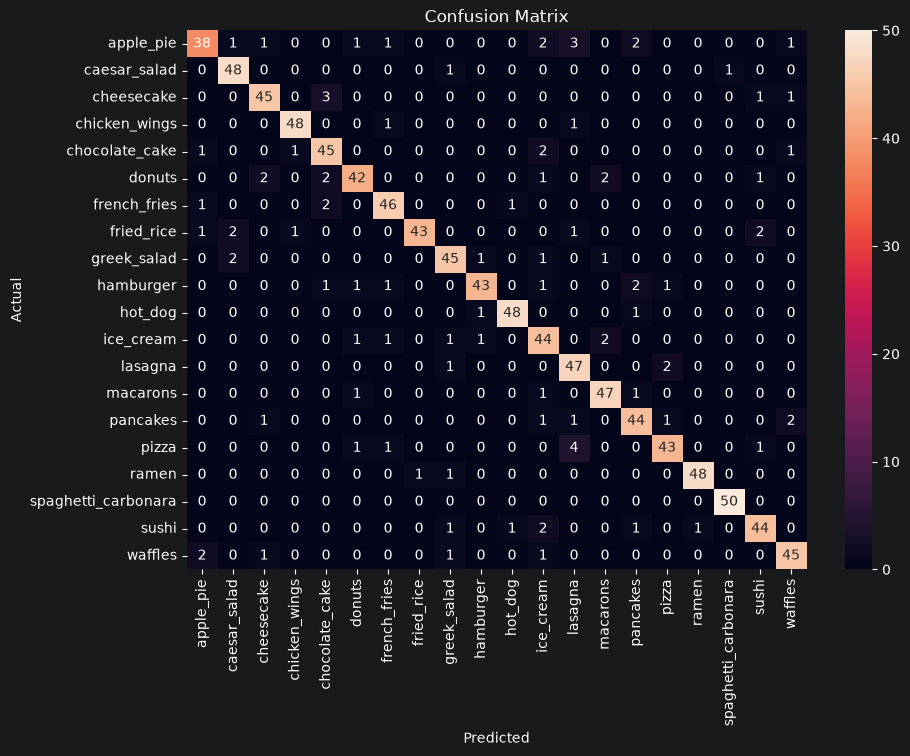

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## 1️⃣7️⃣ Classification ReportPrecision, recall, and F1-score per class.

In [19]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print(report)

                     precision    recall  f1-score   support

          apple_pie     0.8837    0.7600    0.8172        50
       caesar_salad     0.9057    0.9600    0.9320        50
         cheesecake     0.9000    0.9000    0.9000        50
      chicken_wings     0.9600    0.9600    0.9600        50
     chocolate_cake     0.8491    0.9000    0.8738        50
             donuts     0.8936    0.8400    0.8660        50
       french_fries     0.9020    0.9200    0.9109        50
         fried_rice     0.9773    0.8600    0.9149        50
        greek_salad     0.8824    0.9000    0.8911        50
          hamburger     0.9348    0.8600    0.8958        50
            hot_dog     0.9600    0.9600    0.9600        50
          ice_cream     0.7857    0.8800    0.8302        50
            lasagna     0.8246    0.9400    0.8785        50
           macarons     0.9038    0.9400    0.9216        50
           pancakes     0.8627    0.8800    0.8713        50
              pizza    

## 1️⃣8️⃣ Single-Image Prediction FunctionHelper function to run and visualize a prediction on one image, with top-k results.

In [20]:
from PIL import Image
import torch
import matplotlib.pyplot as plt


def predict_image(
    model,
    image_path,
    class_names,
    transform,
    device,
    top_k=5
):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Transform image
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.inference_mode():
        logits = model(image_tensor)

        probabilities = torch.softmax(logits, dim=1)

        top_probs, top_indices = torch.topk(
            probabilities,
            k=top_k,
            dim=1
        )

    top_probs = top_probs[0].cpu()
    top_indices = top_indices[0].cpu()

    # Show image
    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis("off")

    predicted_class = class_names[top_indices[0]]
    predicted_confidence = top_probs[0].item()

    plt.title(
        f"{predicted_class} - {predicted_confidence:.2%}",
        fontsize=14
    )

    plt.show()

    # Print top predictions
    print("Top predictions:")
    print("-" * 30)

    for i in range(top_k):
        class_name = class_names[top_indices[i]]
        confidence = top_probs[i].item()

        print(f"{i+1}. {class_name:<20} {confidence:.2%}")

    return predicted_class, predicted_confidence

## 1️⃣9️⃣ Test on a Sample ImageRun the prediction function on a real sample photo.

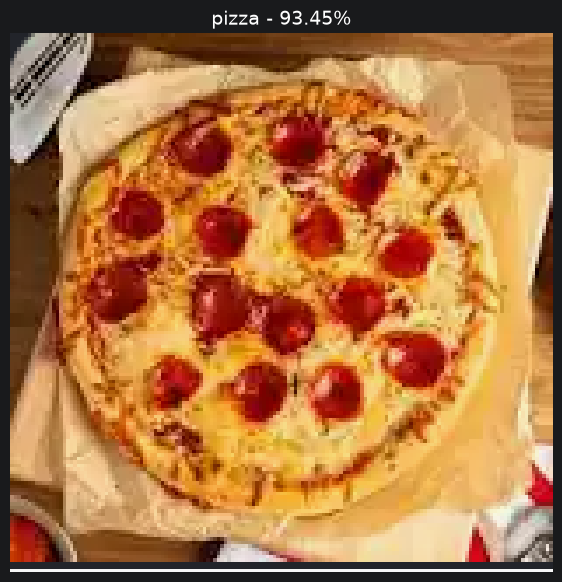

Top predictions:
------------------------------
1. pizza                93.45%
2. lasagna              2.13%
3. apple_pie            1.34%
4. cheesecake           1.08%
5. waffles              0.82%


In [21]:
image_path = r"../photo.jpg"

predicted_class, confidence = predict_image(
    model=model,
    image_path=image_path,
    class_names=class_names,
    transform=auto_transform,
    device=device,
    top_k=5
)

## 2️⃣0️⃣ Model Path Reference (for Deployment)The saved checkpoint path used later when deploying the model (e.g. to Hugging Face Spaces).

In [22]:
best_model_path = "models/best_food_model1.pth"

print(best_model_path)

models/best_food_model1.pth


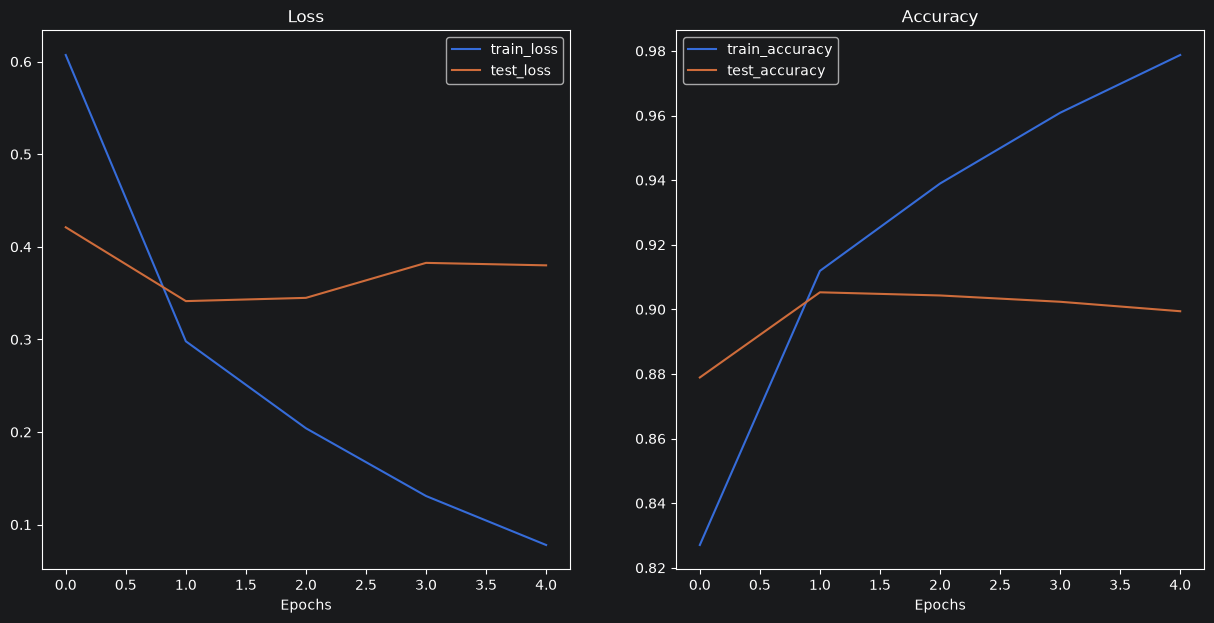

In [23]:
from helper_functions import plot_loss_curves
plot_loss_curves(result)

In [24]:
import torch
import matplotlib.pyplot as plt
import math

# مدل را روی بهترین وزن‌ها قرار بده
model.load_state_dict(
    torch.load("models/best_food_model1.pth", map_location=device)
)

model.eval()

wrong_images = []
wrong_labels = []
wrong_preds = []
wrong_probs = []

with torch.inference_mode():
    for images, labels in test_dataloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        probs, predictions = torch.max(probabilities, dim=1)

        # فقط پیش‌بینی‌های اشتباه
        wrong = predictions != labels

        wrong_images.extend(images[wrong].cpu())
        wrong_labels.extend(labels[wrong].cpu())
        wrong_preds.extend(predictions[wrong].cpu())
        wrong_probs.extend(probs[wrong].cpu())


print(f"Total wrong predictions: {len(wrong_images)}")

Total wrong predictions: 97


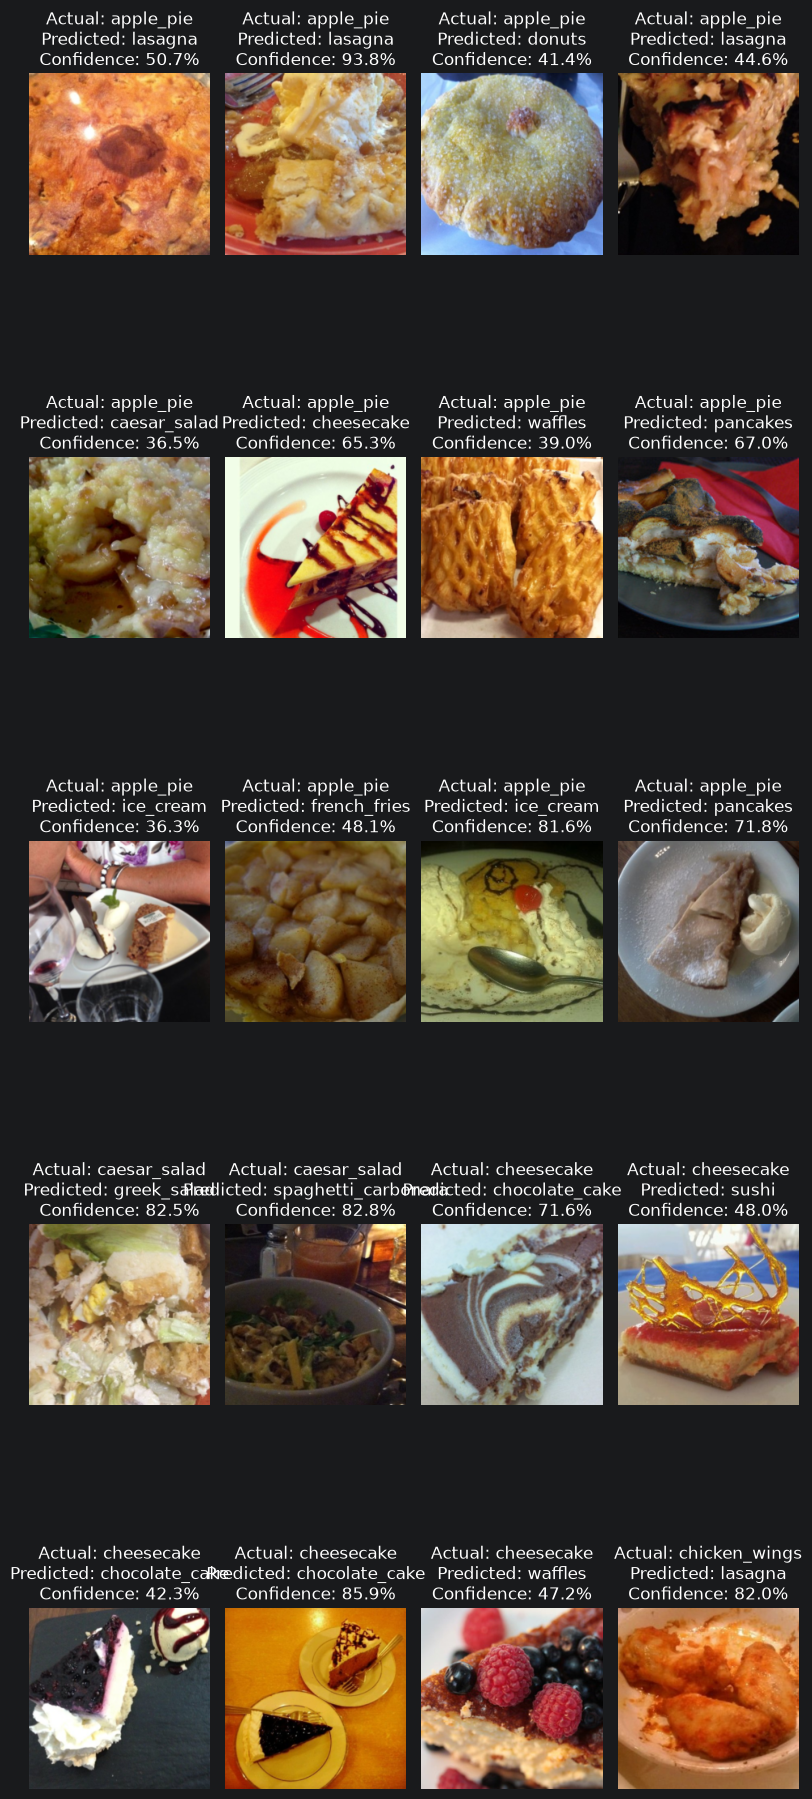

In [25]:
# تعداد تصاویری که می‌خواهیم نمایش بدهیم
num_images = min(20, len(wrong_images))

cols = 4
rows = math.ceil(num_images / cols)

plt.figure(figsize=(8, rows * 4))

for i in range(num_images):

    image = wrong_images[i].permute(1, 2, 0)

    # اگر Normalize شده، برای نمایش برگردانیم
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    actual = class_names[wrong_labels[i]]
    predicted = class_names[wrong_preds[i]]
    confidence = wrong_probs[i].item() * 100

    plt.subplot(rows, cols, i + 1)

    plt.imshow(image)
    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()